# Sample Project-1 (Linear Regression)

🎯 1. Business Problem

“Which distributors contribute most to sales, and where should we expand or optimize?”

📊 2. Dataset Design (Start simple → scalable)

In [1]:
import pandas as pd

data = {
    "region": ["Dhaka", "Dhaka", "Chittagong", "Chittagong", "Khulna", "Khulna"],
    "marketing_spend": [50, 60, 40, 45, 30, 35],
    "price": [90, 88, 92, 91, 95, 94],
    "distributors": [10, 12, 8, 9, 5, 6],
    "sales": [500, 580, 420, 450, 300, 320]
}

df = pd.DataFrame(data)
df

,region,marketing_spend,price,distributors,sales
0,Dhaka,50,90,10,500
1,Dhaka,60,88,12,580
2,Chittagong,40,92,8,420
3,Chittagong,45,91,9,450
4,Khulna,30,95,5,300
5,Khulna,35,94,6,320


🧹 3. Data Preprocessing

In [2]:
# Encode region (categorical → numeric)
df = pd.get_dummies(df, columns=["region"], drop_first=True)

# Features & target
X = df.drop("sales", axis=1)
y = df["sales"]

📈 4. Exploratory Analysis (Quick Insight)

In [4]:
df.corr()

,marketing_spend,price,distributors,sales,region_Dhaka,region_Khulna
marketing_spend,1.000000,-0.992040,0.992040,0.986625,0.836660,-0.776899
price,-0.992040,1.000000,-1.000000,-0.997342,-0.800000,0.850000
distributors,0.992040,-1.000000,1.000000,0.997342,0.800000,-0.850000
sales,0.986625,-0.997342,0.997342,1.000000,0.810945,-0.859360
region_Dhaka,0.836660,-0.800000,0.800000,0.810945,1.000000,-0.500000
region_Khulna,-0.776899,0.850000,-0.850000,-0.859360,-0.500000,1.000000


```bash
👉 Look:

distributors vs sales
region impact

⚙️ 5. Model Building

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

Intercept: 1968.6688311688304
Coefficients: {'marketing_spend': np.float64(-0.324675324675321), 'price': np.float64(-18.311688311688304), 'distributors': np.float64(18.3116883116883), 'region_Dhaka': np.float64(17.500000000000025), 'region_Khulna': np.float64(-18.376623376623428)}


```bash
Model Output:
Intercept: 1968.67
----------------------------
Coefficients:
marketing_spend → -0.32
price           → -18.31
distributors    → +18.31
region_Dhaka    → +17.50
region_Khulna   → -18.38
-------------------------------

🧠 1. Final Model Equation

```bash
Your regression is:
Sales = 1968.67 − 0.32(Marketing) − 18.31(Price) + 18.31(Distributors) +17.50(Dhaka) − 18.38(Khulna)
----------------------------------------------------------------------------------------------------
👉 Base region = Chittagong (because of one-hot encoding with drop_first=True)

🏢 2. Interpret Each Coefficient (Business Meaning)
🔹 Intercept = 1968.67

👉 Baseline sales when all variables = 0
⚠️ Not realistic (since price/marketing can't be 0), but acts as a reference point
------------------------------------------------------------------------------------

🔹 Marketing Spend = -0.32 ❗ (Unexpected)
👉 If marketing increases by 1 unit:

→ Sales decrease by 0.32

⚠️ Interpretation:
This is counterintuitive.
------------------------------------------------------------------------------------
Possible reasons:
Small dataset (only 6 rows)
Multicollinearity (marketing & distributors move together)
Noise / overfitting

👉 Do NOT blindly trust this
------------------------------------------------------------------------------------

🔹 Price = -18.31 ✅
👉 If price increases by 1:

→ Sales drop by 18 units
💡 Strong insight:
High price sensitivity
Pricing is a critical lever
------------------------------------------------------------------------------------

🔹 Distributors = +18.31 🚀

👉 If distributors increase by 1:
→ Sales increase by 18 units

💡 Insight:
Distribution is a major growth driver
Strong ROI area
------------------------------------------------------------------------------------

🔹 Region: Dhaka = +17.5

👉 Compared to Chittagong:
→ Dhaka generates +17.5 more sales
💡 Insight:
Dhaka = high-performing market
------------------------------------------------------------------------------------

🔹 Region: Khulna = -18.38
👉 Compared to Chittagong:

→ Khulna generates 18 units less sales
💡 Insight:
Weak market
Needs strategy rethink
```

📈 5.2 Feature Impact Ranking

| Feature       | Impact                     |
| ------------- | -------------------------- |
| Distributors  | ⭐⭐⭐⭐⭐ (+18.31)             |
| Price         | ⭐⭐⭐⭐⭐ (-18.31)             |
| Region Khulna | ⭐⭐⭐⭐ (-18.38)              |
| Region Dhaka  | ⭐⭐⭐ (+17.5)                |
| Marketing     | ⚠️ negligible / unreliable |


```bash
🧠 4. Key Business Story

Your model is saying:
👉 Sales depends heavily on:

    Distribution (positive)
    Price (negative)

👉 Regional performance varies:

Dhaka → strong
Khulna → weak

👉 Marketing result is unreliable (data issue)

### 🚀 5. Strategic Recommendations

```bash
📦 1. Expand Distributors
Highest positive impact
Focus on Dhaka first
--------------------------------------
💰 2. Optimize Pricing
Very sensitive
Avoid aggressive price increases
--------------------------------------
🗺️ 3. Regional Strategy
Invest more in Dhaka
Reevaluate Khulna (or fix issues)

⚠️ 6. Critical Data Science Insight

```bash
👉 Why marketing is negative?

Because of multicollinearity
Example:
When distributors increase → marketing also increases
Model gets confused → assigns wrong sign

Interview-Level Insight
----------------------------
“Although the model shows a negative coefficient for marketing, this is likely due to multicollinearity or limited data. In practice, I would validate this using correlation analysis and a larger dataset.”
-----------------------------------------------------------------------
🧩 8. Final Mental Model
Intercept → baseline system
Coefficients → marginal impact
Region → market advantage/disadvantage

## 📊 6. Model Evaluation

In [6]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X)

print("R2:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

R2: 0.9969235276882508
RMSE: 5.40061724867327


🧠 7. Business Interpretation (MOST IMPORTANT)

```bash
Example interpretation:

If distributors coefficient = +20
    👉 Each new distributor adds ~20 sales
    
If region_Dhaka = +50
    👉 Dhaka performs better than base region

📦 8. Distributor Performance Ranking

In [7]:
df["predicted_sales"] = y_pred

ranking = df.sort_values(by="predicted_sales", ascending=False)
print(ranking[["distributors", "predicted_sales"]])

   distributors  predicted_sales
1            12            575.0
0            10            505.0
3             9            452.5
2             8            417.5
5             6            327.5
4             5            292.5


🔮 9. Scenario Simulation (Decision Tool)

In [8]:
import pandas as pd

# New scenario
new_data = pd.DataFrame({
    "marketing_spend": [70],
    "price": [88],
    "distributors": [15],
    "region_Dhaka": [1],
    "region_Khulna": [0]
})

prediction = model.predict(new_data)
print("Expected Sales:", prediction[0])

Expected Sales: 626.6883116883116


📊 10. Visualization (Executive Insight)

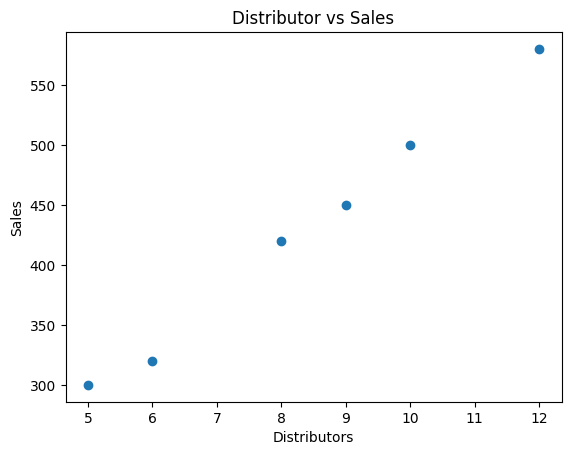

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df["distributors"], df["sales"])
plt.xlabel("Distributors")
plt.ylabel("Sales")
plt.title("Distributor vs Sales")
plt.show()

🏢 11. Final Business Insights (This is your POWER)

```bash
The model shows that distributor count has a strong positive impact on sales. Regions like Dhaka outperform others, indicating higher market potential. Expanding distributor network in high-performing regions can significantly increase revenue

# Chapter 2: Fix Multicollinearity

## Step 1: Detect Multicollinearity

🔍 Correlation check

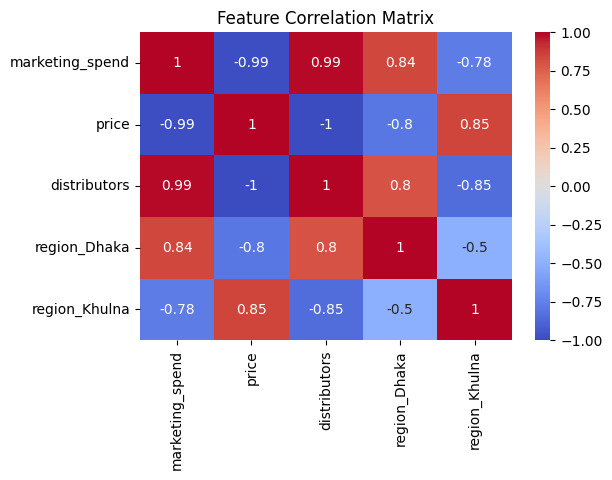

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

⚠️ 3. VIF (Variance Inflation Factor)

In [13]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 4.2 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 4.8 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 4.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 5.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 5.3 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 5.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.0 MB/s  0:00:02

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]


In [15]:
print(X.dtypes)

marketing_spend    int64
price              int64
distributors       int64
region_Dhaka        bool
region_Khulna       bool
dtype: object


In [16]:
# ✅ Step 2: Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')

✅ Step 3: Handle missing values

In [19]:
X = X.fillna(X.mean())

In [20]:
import numpy as np

X_clean = X.values.astype(float)

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_clean, i)
    for i in range(X_clean.shape[1])
]

print(vif_data)

           feature         VIF
0  marketing_spend         inf
1            price  124.022917
2     distributors         inf
3     region_Dhaka    4.111111
4    region_Khulna         inf


c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


📌 Interpretation of VIF

| VIF Value | Meaning                    |
| --------- | -------------------------- |
| 1–5       | OK                         |
| 5–10      | Moderate issue             |
| >10       | ❌ Severe multicollinearity |
